# ch219 — Taylor Series

A Taylor series expresses any smooth function as an infinite polynomial. Every term adds precision. Truncate at N terms and you have an **approximation** — one that works best near the expansion point.

This is how calculators compute sine and cosine. It is also why the second-order term in the loss landscape *(ch218 — Curvature)* is so important in optimisation.

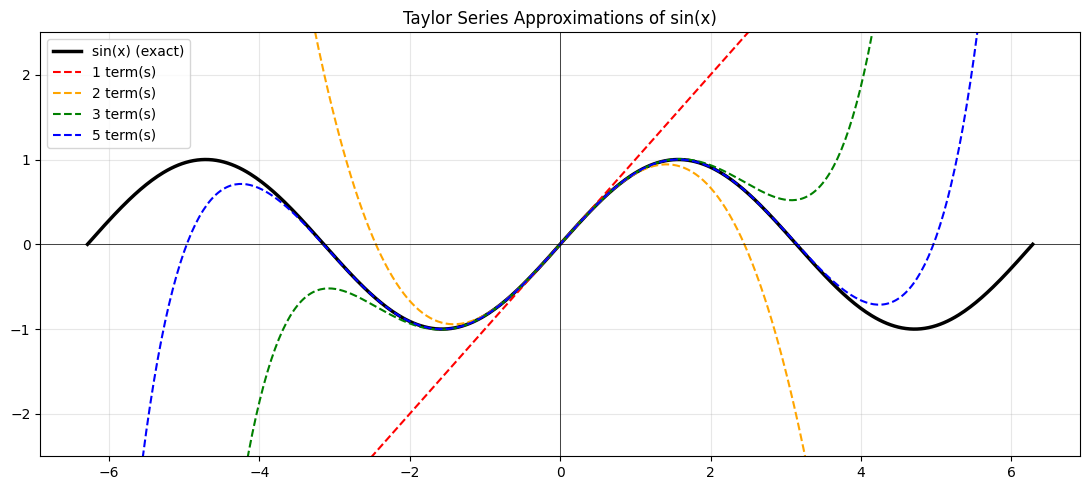

In [1]:
import numpy as np
import matplotlib.pyplot as np_plt
import matplotlib.pyplot as plt

# Taylor series of sin(x) around x=0:
# sin(x) = x - x^3/3! + x^5/5! - x^7/7! + ...

from math import factorial

def taylor_sin(x, n_terms):
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        n = 2*k + 1
        result += ((-1)**k * x**n) / factorial(n)
    return result

x = np.linspace(-2*np.pi, 2*np.pi, 500)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, np.sin(x), 'k', lw=2.5, label='sin(x) (exact)')

for terms, color in [(1,'red'), (2,'orange'), (3,'green'), (5,'blue')]:
    y = taylor_sin(x, terms)
    y = np.clip(y, -3, 3)  # clip for visibility
    ax.plot(x, y, '--', lw=1.5, color=color, label=f'{terms} term(s)')

ax.set_ylim(-2.5, 2.5)
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Taylor Series Approximations of sin(x)')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.savefig('ch219_taylor_sin.png', dpi=100); plt.show()


## The General Formula

For a function f centered at point `a`:

```
f(x) = f(a) + f'(a)(x-a) + f''(a)/2! * (x-a)^2 + f'''(a)/3! * (x-a)^3 + ...
```

Each term uses a higher-order derivative *(ch205, ch217)*. The n-th term captures the n-th order curvature of the function.

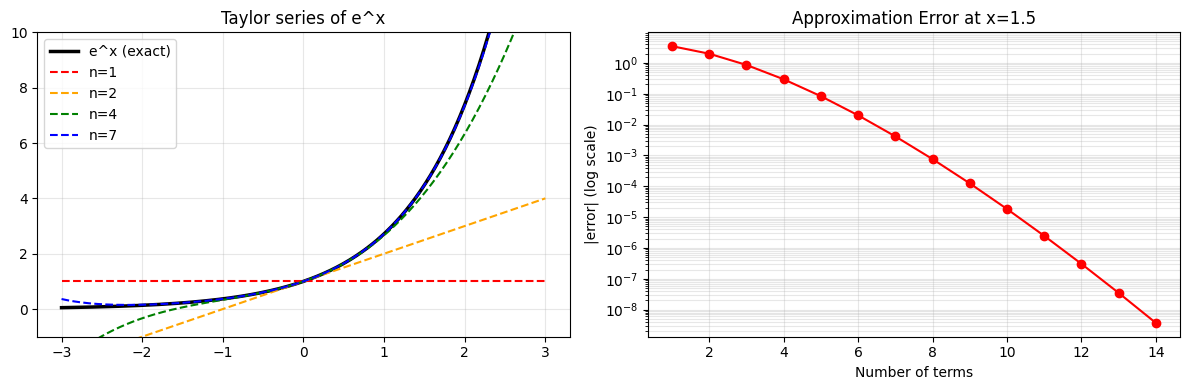

In [2]:
# Taylor series of e^x around x=0
# e^x = 1 + x + x^2/2! + x^3/3! + ...
# Every derivative of e^x is e^x, and e^0 = 1, so all coefficients are 1/n!

def taylor_exp(x, n_terms):
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        result += x**k / factorial(k)
    return result

x = np.linspace(-3, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# e^x
axes[0].plot(x, np.exp(x), 'k', lw=2.5, label='e^x (exact)')
for n, color in [(1,'red'), (2,'orange'), (4,'green'), (7,'blue')]:
    y = np.clip(taylor_exp(x, n), -50, 50)
    axes[0].plot(x, y, '--', lw=1.5, color=color, label=f'n={n}')
axes[0].set_ylim(-1, 10); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_title("Taylor series of e^x")

# Approximation error vs number of terms at x=1.5
errors = []
for n in range(1, 15):
    approx = sum((1.5**k / factorial(k)) for k in range(n))
    errors.append(abs(approx - np.exp(1.5)))
axes[1].semilogy(range(1, 15), errors, 'o-', color='red')
axes[1].set_xlabel('Number of terms'); axes[1].set_ylabel('|error| (log scale)')
axes[1].set_title('Approximation Error at x=1.5'); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.savefig('ch219_taylor_exp.png', dpi=100); plt.show()


## Taylor Series in Machine Learning

The **second-order Taylor expansion** of the loss `L(w)` around current weights `w_0` is:

```
L(w) ≈ L(w_0) + g^T (w - w_0) + 0.5 * (w - w_0)^T H (w - w_0)
```

Where `g` is the gradient and `H` is the Hessian. This is the foundation of Newton's method and second-order optimisers.

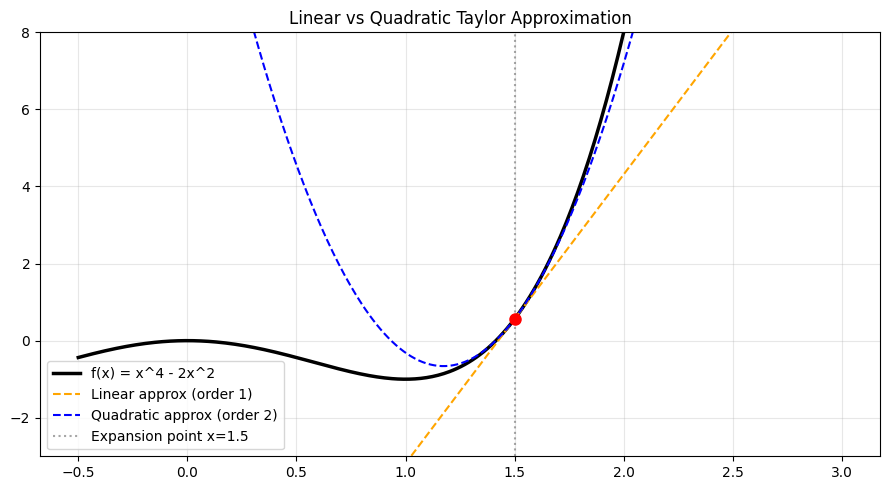

In [3]:
# Quadratic approximation (Taylor order 2) of f(x) = x^4 - 2x^2 at x0 = 1.5
def f(x): return x**4 - 2*x**2
def f1(x): return 4*x**3 - 4*x
def f2(x): return 12*x**2 - 4

x0 = 1.5
x = np.linspace(-0.5, 3.0, 400)

# Taylor expansion around x0
quad_approx = f(x0) + f1(x0)*(x - x0) + 0.5*f2(x0)*(x - x0)**2
linear_approx = f(x0) + f1(x0)*(x - x0)

plt.figure(figsize=(9, 5))
plt.plot(x, f(x), 'k', lw=2.5, label='f(x) = x^4 - 2x^2')
plt.plot(x, linear_approx, '--', color='orange', lw=1.5, label='Linear approx (order 1)')
plt.plot(x, quad_approx, '--', color='blue', lw=1.5, label='Quadratic approx (order 2)')
plt.axvline(x0, color='gray', ls=':', alpha=0.7, label=f'Expansion point x={x0}')
plt.plot(x0, f(x0), 'ro', ms=8)
plt.ylim(-3, 8); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Linear vs Quadratic Taylor Approximation')
plt.tight_layout(); plt.savefig('ch219_quad_approx.png', dpi=100); plt.show()


## Summary

| Concept | Key Point |
|---|---|
| Taylor series | Polynomial representation of smooth functions |
| Convergence radius | Approximation accurate only near expansion point |
| Order 1 term | Gradient — direction of steepest ascent |
| Order 2 term | Curvature — how gradient itself changes |
| Truncation | More terms = larger region of accuracy |

**Forward reference:** ch220 — Approximation explores how truncated Taylor series are used computationally for transcendental functions.